# Classic aggregation methods beyond TOPSIS and ELECTRE

`skcriteria.agg` implements more than twenty complete MCDA methods. The
[Quick Start](quickstart.ipynb) only introduced `TOPSIS` and `ELECTRE1`;
this tutorial tours the rest, grouped in four families that share a
common idea, and closes by running (almost) all of them on the same
dataset to see how much the *choice of method* can change a ranking.

Every example below uses a decision matrix taken from the paper that
originally introduced (or popularized) the corresponding method, so the
numbers can be cross-checked against the literature.

<div class="alert alert-info">

**A recurring detail:** most of these methods require every criterion to
be `Maximize` and, several of them, strictly positive values too. We
will use `BenefitCostInverter` (introduced in the
[Inverting objectives](invert_objectives.ipynb) tutorial) to satisfy
both requirements in a single step whenever needed.

</div>

## 1. The weighted sum/product family: `WeightedSumModel`, `WeightedProductModel`, `WASPAS`

- `WeightedSumModel` (already used in the [Quick Start](quickstart.ipynb)
  and [Scaling and weighting criteria](scale_weight.ipynb) tutorials)
  scores every alternative as $\sum_j w_j a_{ij}$: a weighted **sum**.
- `WeightedProductModel` scores every alternative as
  $\prod_j a_{ij}^{w_j}$: a weighted **product**. Being multiplicative,
  a very poor value in a single criterion drags the whole score down
  much harder than in `WeightedSumModel` — it is *less compensatory*.
  This contrast between the two is precisely the "decision-making
  paradox" studied by
  <cite data-cite="triantaphyllou1989examination">[triantaphyllou1989examination]</cite>.
- `WASPAS` (Weighted Aggregated Sum Product ASsessment) blends both:
  $A_i = \lambda \sum_j w_j a_{ij} + (1-\lambda) \prod_j a_{ij}^{w_j}$,
  with $\lambda=1$ equivalent to `WeightedSumModel`, $\lambda=0$
  equivalent to `WeightedProductModel`, and the default $\lambda=0.5$ in
  between <cite data-cite="zavadskas2012optimization">[zavadskas2012optimization]</cite>.

We reuse the stock-selection dataset from the
[Quick Start](quickstart.ipynb)/[Dominance](sufdom.ipynb) tutorials.

In [1]:
from skcriteria.datasets import load_simple_stock_selection
from skcriteria.preprocessing import invert_objectives

dm = load_simple_stock_selection()
dmb = invert_objectives.BenefitCostInverter().transform(dm)
dmb

,ROE[▲ 2.0],CAP[▲ 4.0],RI[▲ 1.0]
PE,1.000000,0.625,0.742857
JN,0.714286,0.500,1.000000
AA,0.714286,0.750,0.928571
FX,0.428571,0.500,0.722222
MM,0.142857,0.875,0.866667
GN,0.714286,1.000,0.866667


In [2]:
from skcriteria.agg.simple import WeightedSumModel, WeightedProductModel
from skcriteria.agg.waspas import WASPAS

wsm = WeightedSumModel().evaluate(dmb)
wpm = WeightedProductModel().evaluate(dmb)
waspas_wsm = WASPAS(lambda_value=1.0).evaluate(dmb)  # == WeightedSumModel
waspas_wpm = WASPAS(lambda_value=0.0).evaluate(dmb)  # == WeightedProductModel
waspas_mid = WASPAS().evaluate(dmb)  # lambda_value=0.5 (default)

display(wsm, wpm, waspas_mid)

Alternatives,PE,JN,AA,FX,MM,GN
Rank,3,5,2,6,4,1


Alternatives,PE,JN,AA,FX,MM,GN
Rank,3,4,2,6,5,1


Alternatives,PE,JN,AA,FX,MM,GN
Rank,3,5,2,6,4,1


`WeightedSumModel` and `WeightedProductModel` already disagree on this
tiny dataset: `JN` and `MM` swap positions (5th/4th) between the two.
`WASPAS` with the default $\lambda=0.5$ happens to land on the same
ranking as `WeightedSumModel` here, and we can confirm the two extreme
cases match exactly by construction:

In [3]:
import numpy as np

assert np.all(waspas_wsm.values == wsm.values)
assert np.all(waspas_wpm.values == wpm.values)
print("WASPAS(lambda=1.0) == WeightedSumModel, WASPAS(lambda=0.0) == WeightedProductModel")

WASPAS(lambda=1.0) == WeightedSumModel, WASPAS(lambda=0.0) == WeightedProductModel


## 2. The MOORA family: `RatioMOORA`, `ReferencePointMOORA`, `FullMultiplicativeForm`, `MultiMOORA`

MOORA (Multi-Objective Optimization by Ratio Analysis) is not a single
method but a small family that shares the same vector-normalized matrix
and combines it in four different ways
<cite data-cite="brauers2006moora">[brauers2006moora]</cite>:

- `RatioMOORA`: subtracts the (weighted) sum of `Minimize` criteria from
  the sum of `Maximize` criteria.
- `ReferencePointMOORA`: builds a reference point with the best value of
  each criterion and ranks alternatives by their *maximum* deviation
  from it (a min-max, non-compensatory criterion).
- `FullMultiplicativeForm`: divides the product of `Maximize` values by
  the product of `Minimize` values (requires strictly positive data).
- `MultiMOORA`: runs the three methods above and aggregates their
  rankings using a dominance-theory tie-break
  <cite data-cite="brauers2012robustness">[brauers2012robustness]</cite>.

We use the building-heating-losses matrix from
<cite data-cite="brauers2006moora">[brauers2006moora]</cite>, which mixes
five `Minimize` and two `Maximize` criteria — the MOORA family handles
mixed objectives natively, no inversion needed.

In [4]:
import skcriteria as skc

moora_dm = skc.mkdm(
    matrix=[
        [33.95, 23.78, 11.45, 39.97, 29.44, 167.10, 3.852],
        [38.90, 4.17, 6.32, 0.01, 4.29, 132.52, 25.184],
        [37.59, 9.36, 8.23, 4.35, 10.22, 136.71, 10.845],
        [30.44, 37.59, 13.91, 74.08, 45.10, 198.34, 2.186],
        [36.21, 14.79, 9.17, 17.77, 17.06, 148.30, 6.610],
        [37.80, 8.55, 7.97, 2.35, 9.25, 134.83, 11.935],
    ],
    objectives=[min, min, min, min, max, min, max],
    alternatives=["A1", "A2", "A3", "A4", "A5", "A6"],
    criteria=["x1", "x2", "x3", "x4", "x5", "x6", "x7"],
)
moora_dm

,x1[▼ 1.0],x2[▼ 1.0],x3[▼ 1.0],x4[▼ 1.0],x5[▲ 1.0],x6[▼ 1.0],x7[▲ 1.0]
A1,33.95,23.78,11.45,39.97,29.44,167.10,3.852
A2,38.90,4.17,6.32,0.01,4.29,132.52,25.184
A3,37.59,9.36,8.23,4.35,10.22,136.71,10.845
A4,30.44,37.59,13.91,74.08,45.10,198.34,2.186
A5,36.21,14.79,9.17,17.77,17.06,148.30,6.610
A6,37.80,8.55,7.97,2.35,9.25,134.83,11.935


In [5]:
from skcriteria.agg.moora import (
    RatioMOORA,
    ReferencePointMOORA,
    FullMultiplicativeForm,
    MultiMOORA,
)
from skcriteria.cmp import mkrank_cmp

ratio = RatioMOORA().evaluate(moora_dm)
refpoint = ReferencePointMOORA().evaluate(moora_dm)
fmf = FullMultiplicativeForm().evaluate(moora_dm)
multi = MultiMOORA().evaluate(moora_dm)

rcmp = mkrank_cmp(ratio, refpoint, fmf, multi)
rcmp.to_dataframe()

Method,RatioMOORA,ReferencePointMOORA,FullMultiplicativeForm,MultiMOORA
Alternatives,,,,
A1,5,4,5,5
A2,1,5,1,1
A3,3,2,3,3
A4,6,6,6,6
A5,4,1,4,4
A6,2,3,2,2


`RatioMOORA`, `FullMultiplicativeForm` and `MultiMOORA` agree on every
single alternative here — `MultiMOORA` simply confirms the consensus of
its three sub-methods. `ReferencePointMOORA` tells a different story
(compare `A1`/`A2`/`A5`), because it only looks at the *single worst*
deviation from the ideal instead of compensating across all criteria.

## 3. Distance-to-ideal-solution family: `VIKOR`, `CODAS`, `MABAC`, `MAIRCA`

These four methods all rank alternatives by some notion of *distance* to
an ideal/anti-ideal or "border" solution, but each defines that distance
differently:

- `VIKOR`: balances group utility ($S$, an aggregated normalized
  distance to the ideal) against individual regret ($R$, the worst
  single-criterion distance), combined into a compromise index $Q$
  <cite data-cite="opricovic2004compromise">[opricovic2004compromise]</cite>.
- `CODAS`: ranks by Euclidean distance to the negative-ideal solution,
  using Taxicab (Manhattan) distance as a tie-breaker
  <cite data-cite="ghorabaee2016new">[ghorabaee2016new]</cite>.
- `MABAC`: computes, for every alternative and criterion, the distance to
  a "border approximation area" (a geometric mean of the normalized
  matrix) and sums it up
  <cite data-cite="pamucar20153016">[pamucar20153016]</cite>.
- `MAIRCA`: compares a theoretical ("what an ideal alternative would
  score") rating against the real one, and sums the gap
  <cite data-cite="dragan2018hybrid">[dragan2018hybrid]</cite>.

We use the forklift-selection matrix (7 alternatives, 10 criteria) from
the original `MABAC` paper.

In [6]:
mabac_dm = skc.mkdm(
    matrix=[
        [22600, 3800, 2, 5, 1.06, 3.00, 3.5, 2.8, 24.5, 6.5],
        [19500, 4200, 3, 2, 0.95, 3.00, 3.4, 2.2, 24.0, 7.0],
        [21700, 4000, 1, 3, 1.25, 3.20, 3.3, 2.5, 24.5, 7.3],
        [20600, 3800, 2, 5, 1.05, 3.25, 3.2, 2.0, 22.5, 11.0],
        [22500, 3800, 4, 3, 1.35, 3.20, 3.7, 2.1, 23.0, 6.3],
        [23250, 4210, 3, 5, 1.45, 3.60, 3.5, 2.8, 23.5, 7.0],
        [20300, 3850, 2, 5, 0.90, 3.25, 3.0, 2.6, 21.5, 6.0],
    ],
    objectives=[min, max, max, max, min, min, max, max, max, max],
    weights=[0.146, 0.144, 0.119, 0.121, 0.115, 0.101, 0.088, 0.068, 0.050, 0.048],
    alternatives=[f"Forklift {i}" for i in range(1, 8)],
    criteria=[f"C{i}" for i in range(1, 11)],
)
mabac_dmb = invert_objectives.BenefitCostInverter().transform(mabac_dm)
mabac_dmb

,C1[▲ 0.146],C2[▲ 0.144],C3[▲ 0.119],C4[▲ 0.121],C5[▲ 0.115],C6[▲ 0.101],C7[▲ 0.088],C8[▲ 0.068],C9[▲ 0.050],C10[▲ 0.048]
Forklift 1,0.862832,0.902613,0.50,1.0,0.849057,1.000000,0.945946,1.000000,1.000000,0.590909
Forklift 2,1.000000,0.997625,0.75,0.4,0.947368,1.000000,0.918919,0.785714,0.979592,0.636364
Forklift 3,0.898618,0.950119,0.25,0.6,0.720000,0.937500,0.891892,0.892857,1.000000,0.663636
Forklift 4,0.946602,0.902613,0.50,1.0,0.857143,0.923077,0.864865,0.714286,0.918367,1.000000
Forklift 5,0.866667,0.902613,1.00,0.6,0.666667,0.937500,1.000000,0.750000,0.938776,0.572727
Forklift 6,0.838710,1.000000,0.75,1.0,0.620690,0.833333,0.945946,1.000000,0.959184,0.636364
Forklift 7,0.960591,0.914489,0.50,1.0,1.000000,0.923077,0.810811,0.928571,0.877551,0.545455


In [7]:
from skcriteria.agg.vikor import VIKOR
from skcriteria.agg.codas import CODAS
from skcriteria.agg.mabac import MABAC
from skcriteria.agg.mairca import MAIRCA

vikor = VIKOR().evaluate(mabac_dmb)
codas = CODAS().evaluate(mabac_dmb)
mabac = MABAC().evaluate(mabac_dmb)
mairca = MAIRCA().evaluate(mabac_dmb)

rcmp_dist = mkrank_cmp(vikor, codas, mabac, mairca)
rcmp_dist.to_dataframe()

Method,VIKOR,CODAS,MABAC,MAIRCA
Alternatives,,,,
Forklift 1,4,4,2,2
Forklift 2,1,6,5,1
Forklift 3,3,7,7,6
Forklift 4,6,5,4,5
Forklift 5,7,3,6,7
Forklift 6,5,1,3,3
Forklift 7,2,2,1,4


In [8]:
rcmp_dist.corr()

Method,VIKOR,CODAS,MABAC,MAIRCA
Method,,,,
VIKOR,1.000000,-0.238095,0.238095,0.523810
CODAS,-0.238095,1.000000,0.523810,0.047619
MABAC,0.238095,0.523810,1.000000,0.333333
MAIRCA,0.523810,0.047619,0.333333,1.000000


The four rankings disagree substantially (`VIKOR` and `CODAS` even
correlate *negatively*, $-0.24$). `Forklift 1` and `Forklift 7` are
picked as the winner depending on the method, which is a good reminder
that "distance to an ideal solution" is not a single well-defined idea —
each method operationalizes it differently, and the right pick usually
depends on which trade-off (compensatory sum vs. worst-case gap vs.
border area) fits the decision-maker's intent.

## 4. Ranking/comparison family: `ARAS`, `COPRAS`, `CoCoSo`, `EDAS`, `MARCOS`, `OCRA`, `RAM`

The largest family: every one of these methods scores alternatives by
comparing them against some aggregate reference (an ideal solution, the
*average* alternative, or an anti-ideal), but the aggregation formula
differs method by method:

- `ARAS`: ratio of each alternative's utility to the utility of an ideal
  (best-possible) alternative
  <cite data-cite="zavadskas2010new">[zavadskas2010new]</cite>.
- `COPRAS`: sums `Maximize` and `Minimize` criteria **separately** and
  combines both sums into a single utility degree — unlike the other
  methods here, it consumes the mixed-objective matrix directly, without
  inverting it first
  <cite data-cite="zavadskas1996new">[zavadskas1996new]</cite>.
- `CoCoSo`: combines a weighted-sum and a weighted-product strategy
  (much like `WASPAS`) with power-weighted and additive aggregations of
  the two <cite data-cite="yazdani2019cocoso">[yazdani2019cocoso]</cite>.
- `EDAS`: instead of distances to an ideal, it measures each
  alternative's positive/negative distance **from the average**
  alternative <cite data-cite="keshavarz2015multi">[keshavarz2015multi]</cite>.
- `MARCOS`: compares each alternative to both an ideal and an anti-ideal
  reference and derives a compromise utility function
  <cite data-cite="stevic2019sustainable">[stevic2019sustainable]</cite>.
- `OCRA`: builds separate "competitiveness ratings" for benefit and cost
  criteria and combines them
  <cite data-cite="parkan1994ocra">[parkan1994ocra]</cite>.
- `RAM`: Root Assessment Method — a recent, simple ratio-based method
  designed to be resistant to rank-reversal
  <cite data-cite="SOTOUDEHANVARI2023138695">[SOTOUDEHANVARI2023138695]</cite>.

We use the hotel-selection matrix from
<cite data-cite="tus2016ocra">[tus2016ocra]</cite> (the `OCRA` example
used elsewhere in this documentation).

In [9]:
hotel_dm = skc.mkdm(
    matrix=[
        [7.7, 256, 7.2, 7.3, 7.3],
        [8.1, 250, 7.9, 7.8, 7.7],
        [8.7, 352, 8.6, 7.9, 8.0],
        [8.1, 262, 7.0, 8.1, 7.2],
        [6.5, 271, 6.3, 6.4, 6.1],
        [6.8, 228, 7.1, 7.2, 6.5],
    ],
    objectives=[max, min, max, max, max],
    weights=[0.239, 0.225, 0.197, 0.186, 0.153],
    alternatives=["A1", "A2", "A3", "A4", "A5", "A6"],
    criteria=["C1", "C2", "C3", "C4", "C5"],
)
hotel_dmb = invert_objectives.BenefitCostInverter().transform(hotel_dm)
hotel_dmb

,C1[▲ 0.239],C2[▲ 0.225],C3[▲ 0.197],C4[▲ 0.186],C5[▲ 0.153]
A1,0.885057,0.890625,0.837209,0.901235,0.9125
A2,0.931034,0.912000,0.918605,0.962963,0.9625
A3,1.000000,0.647727,1.000000,0.975309,1.0000
A4,0.931034,0.870229,0.813953,1.000000,0.9000
A5,0.747126,0.841328,0.732558,0.790123,0.7625
A6,0.781609,1.000000,0.825581,0.888889,0.8125


In [10]:
from skcriteria.agg.aras import ARAS
from skcriteria.agg.copras import COPRAS
from skcriteria.agg.cocoso import CoCoSo
from skcriteria.agg.edas import EDAS
from skcriteria.agg.marcos import MARCOS
from skcriteria.agg.ocra import OCRA
from skcriteria.agg.ram import RAM

aras = ARAS().evaluate(hotel_dmb)
copras = COPRAS().evaluate(hotel_dm)  # works on the original, mixed-objective matrix
cocoso = CoCoSo().evaluate(hotel_dmb)
edas = EDAS().evaluate(hotel_dmb)
marcos = MARCOS().evaluate(hotel_dmb)
ocra = OCRA().evaluate(hotel_dmb)
ram = RAM().evaluate(hotel_dmb)

rcmp_family = mkrank_cmp(aras, copras, cocoso, edas, marcos, ocra, ram)
rcmp_family.to_dataframe()

Method,ARAS,COPRAS,CoCoso,EDAS,MARCOS,OCRA,RAM
Alternatives,,,,,,,
A1,4,3,4,4,4,4,4
A2,1,2,1,1,1,1,1
A3,2,6,2,2,2,2,2
A4,3,4,3,3,3,3,3
A5,6,5,6,6,6,6,6
A6,5,1,5,5,5,5,5


Six of the seven methods agree on every alternative, which shows that,
for a well-behaved dataset, this whole family tends to converge — they
are, after all, variations on the same "compare to a reference" idea.
`COPRAS` is the outlier: because it keeps `Minimize` and `Maximize`
criteria in two separate sums instead of folding everything into one
normalized, all-benefit matrix like the others, it weighs the trade-off
between `C1`/`C3`/`C4`/`C5` (benefit) and `C2` (cost) differently enough
to produce an almost uncorrelated ranking.

In [11]:
rcmp_family.corr()

Method,ARAS,COPRAS,CoCoso,EDAS,MARCOS,OCRA,RAM
Method,,,,,,,
ARAS,1.000000,-0.066667,1.000000,1.000000,1.000000,1.000000,1.000000
COPRAS,-0.066667,1.000000,-0.066667,-0.066667,-0.066667,-0.066667,-0.066667
CoCoso,1.000000,-0.066667,1.000000,1.000000,1.000000,1.000000,1.000000
EDAS,1.000000,-0.066667,1.000000,1.000000,1.000000,1.000000,1.000000
MARCOS,1.000000,-0.066667,1.000000,1.000000,1.000000,1.000000,1.000000
OCRA,1.000000,-0.066667,1.000000,1.000000,1.000000,1.000000,1.000000
RAM,1.000000,-0.066667,1.000000,1.000000,1.000000,1.000000,1.000000


## 5. Grand comparison: (almost) every method on the same dataset

Let's close by running every method introduced in this tutorial — 18 in
total — on the same, single dataset: the stock-selection matrix from
Part 1. `COPRAS` is the only one evaluated on the original mixed-objective
matrix `dm`; every other method uses the `BenefitCostInverter`-transformed
`dmb`.

In [12]:
methods = {
    "WeightedSumModel": WeightedSumModel(),
    "WeightedProductModel": WeightedProductModel(),
    "WASPAS": WASPAS(),
    "RatioMOORA": RatioMOORA(),
    "ReferencePointMOORA": ReferencePointMOORA(),
    "FullMultiplicativeForm": FullMultiplicativeForm(),
    "MultiMOORA": MultiMOORA(),
    "VIKOR": VIKOR(),
    "CODAS": CODAS(),
    "MABAC": MABAC(),
    "MAIRCA": MAIRCA(),
    "ARAS": ARAS(),
    "CoCoSo": CoCoSo(),
    "EDAS": EDAS(),
    "MARCOS": MARCOS(),
    "OCRA": OCRA(),
    "RAM": RAM(),
}

rankings = [m.evaluate(dmb) for m in methods.values()]
rankings.append(COPRAS().evaluate(dm))

rcmp_all = mkrank_cmp(*rankings)
rcmp_all.to_dataframe()

Method,WeightedSumModel,WeightedProductModel,WASPAS,RatioMOORA,ReferencePointMOORA,FullMultiplicativeForm,MultiMOORA,VIKOR,CODAS,MABAC,MAIRCA,ARAS,CoCoso,EDAS,MARCOS,OCRA,RAM,COPRAS
Alternatives,,,,,,,,,,,,,,,,,,
PE,3,3,3,3,3,3,3,4,2,3,4,3,2,3,3,1,3,5
JN,5,4,5,5,5,4,5,5,5,5,5,5,4,5,5,4,5,3
AA,2,2,2,2,2,2,2,2,3,2,2,2,3,2,2,3,2,2
FX,6,6,6,6,5,5,5,6,6,6,6,6,6,6,6,5,6,6
MM,4,5,4,4,4,6,4,3,4,4,3,4,5,4,4,6,4,4
GN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1


In [13]:
rcmp_all.corr()

Method,WeightedSumModel,WeightedProductModel,WASPAS,RatioMOORA,ReferencePointMOORA,FullMultiplicativeForm,MultiMOORA,VIKOR,CODAS,MABAC,MAIRCA,ARAS,CoCoso,EDAS,MARCOS,OCRA,RAM,COPRAS
Method,,,,,,,,,,,,,,,,,,
WeightedSumModel,1.000000,0.866667,1.000000,1.000000,0.966092,0.733333,0.966092,0.866667,0.866667,1.000000,0.866667,1.000000,0.733333,1.000000,1.000000,0.466667,1.000000,0.600000
WeightedProductModel,0.866667,1.000000,0.866667,0.866667,0.828079,0.866667,0.828079,0.733333,0.733333,0.866667,0.733333,0.866667,0.866667,0.866667,0.866667,0.600000,0.866667,0.733333
WASPAS,1.000000,0.866667,1.000000,1.000000,0.966092,0.733333,0.966092,0.866667,0.866667,1.000000,0.866667,1.000000,0.733333,1.000000,1.000000,0.466667,1.000000,0.600000
RatioMOORA,1.000000,0.866667,1.000000,1.000000,0.966092,0.733333,0.966092,0.866667,0.866667,1.000000,0.866667,1.000000,0.733333,1.000000,1.000000,0.466667,1.000000,0.600000
ReferencePointMOORA,0.966092,0.828079,0.966092,0.966092,1.000000,0.690066,1.000000,0.828079,0.828079,0.966092,0.828079,0.966092,0.690066,0.966092,0.966092,0.414039,0.966092,0.552052
FullMultiplicativeForm,0.733333,0.866667,0.733333,0.733333,0.690066,1.000000,0.690066,0.600000,0.600000,0.733333,0.600000,0.733333,0.733333,0.733333,0.733333,0.733333,0.733333,0.600000
MultiMOORA,0.966092,0.828079,0.966092,0.966092,1.000000,0.690066,1.000000,0.828079,0.828079,0.966092,0.828079,0.966092,0.690066,0.966092,0.966092,0.414039,0.966092,0.552052
VIKOR,0.866667,0.733333,0.866667,0.866667,0.828079,0.600000,0.828079,1.000000,0.733333,0.866667,1.000000,0.866667,0.600000,0.866667,0.866667,0.333333,0.866667,0.733333
CODAS,0.866667,0.733333,0.866667,0.866667,0.828079,0.600000,0.828079,0.733333,1.000000,0.866667,0.733333,0.866667,0.866667,0.866667,0.866667,0.600000,0.866667,0.466667


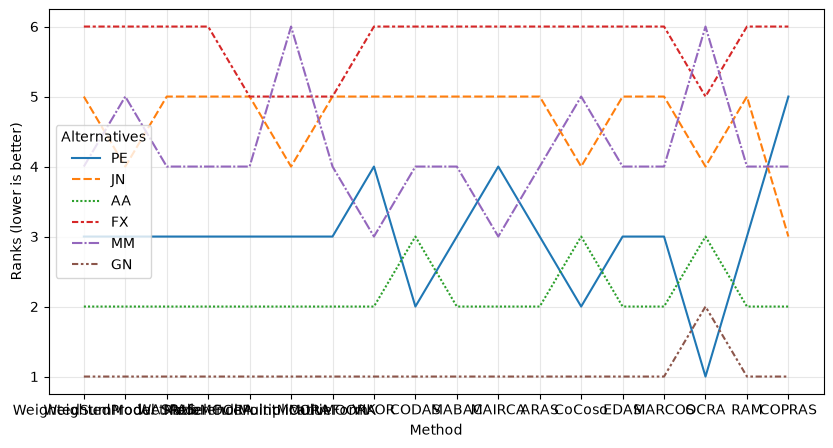

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
rcmp_all.plot.flow(ax=ax);

Even on a tiny 6-alternative, 3-criteria dataset, 18 methods produce a
noticeable spread of opinions about who the winner is: `GN` and `AA`
dominate the top of almost every ranking, but `PE` and `MM` swap places
several times, and `COPRAS` alone disagrees on almost everything (as
already seen in Part 4). None of this means any of the methods is
"wrong" — each one encodes a different, perfectly reasonable notion of
what makes an alternative good. In practice:

- If the methods largely agree (as in Part 2 and most of Part 4), the
  choice of method barely matters — pick the one that is easiest to
  explain to the decision-maker.
- If they disagree (as in Part 3, or `COPRAS` vs. the rest here), that
  disagreement is itself useful information: it means the ranking is
  sensitive to *how* trade-offs are modeled, and the decision-maker
  should be involved in choosing which notion of "distance" or
  "compensation" actually matches their intent, rather than trusting a
  single method blindly.